In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.feature_selection import RFECV

# 设置中文字体（Mac/Win 通用）
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 固定随机种子，保证每次运行结果一样
np.random.seed(42)

print("=" * 60)
print("🏦 风控决策树模拟实验")
print("=" * 60)

🏦 风控决策树模拟实验


In [3]:
# ============ 生成模拟数据 ============
n_samples = 10000

# 真实有效的特征（有逻辑的）
fico = np.random.normal(700, 80, n_samples).astype(int)
fico = np.clip(fico, 350, 850)  # 限制在 FICO 范围内

income = np.random.normal(70000, 30000, n_samples).astype(int)
income = np.clip(income, 15000, 300000)

dti = np.random.normal(30, 15, n_samples)  # 负债比 (Debt-to-Income)
dti = np.clip(dti, 0, 70)

# 高基数“作弊”特征（类似身份证号后几位、邮编等）
# 这个特征和违约没有任何逻辑关系，但因为取值多，决策树会误以为它很重要
fake_id = np.random.randint(0, 1000, n_samples)  # 1000 种取值

# 生成标签（违约概率）：FICO 越低、DTI 越高，越容易违约
logit = -0.03 * (fico - 700) + 0.05 * dti + np.random.normal(0, 0.5, n_samples)
prob = 1 / (1 + np.exp(-logit))
y = (prob > 0.5).astype(int)

# 拼成 DataFrame
df = pd.DataFrame({
    'FICO': fico,
    '收入': income,
    '负债比_DTI': dti,
    '工作年限': np.random.randint(0, 30, n_samples),
    '信用卡使用率': np.random.uniform(0, 1, n_samples),
    '虚假ID_高基数': fake_id,  # 👈 这就是那个“作弊”特征
    '违约标签': y
})

print(f"✅ 生成了 {len(df)} 条模拟数据")
print(f"坏账率: {y.mean():.2%}")
print("\n前 5 行数据：")
df.head()

✅ 生成了 10000 条模拟数据
坏账率: 72.20%

前 5 行数据：


,FICO,收入,负债比_DTI,工作年限,信用卡使用率,虚假ID_高基数,违约标签
0,739,49645,35.224294,4,0.596621,891,1
1,688,60835,34.249854,28,0.313074,497,1
2,751,52078,15.952202,4,0.862804,959,0
3,821,73312,38.693763,14,0.054158,875,0
4,681,105915,7.648760,16,0.899751,963,1


In [4]:
X = df.drop('违约标签', axis=1)
y = df['违约标签']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"训练集: {len(X_train)} 条")
print(f"测试集: {len(X_test)} 条")
print(f"训练集坏账率: {y_train.mean():.2%}")
print(f"测试集坏账率: {y_test.mean():.2%}")

训练集: 7000 条
测试集: 3000 条
训练集坏账率: 72.16%
测试集坏账率: 72.30%


In [5]:
# ============ 用 Gini 训练 ============
tree_gini = DecisionTreeClassifier(
    max_depth=4,           # 限制深度，方便可视化
    criterion='gini',
    random_state=42
)
tree_gini.fit(X_train, y_train)

# ============ 用 Entropy 训练 ============
tree_entropy = DecisionTreeClassifier(
    max_depth=4,
    criterion='entropy',
    random_state=42
)
tree_entropy.fit(X_train, y_train)

# 对比测试集 AUC
auc_gini = roc_auc_score(y_test, tree_gini.predict_proba(X_test)[:, 1])
auc_entropy = roc_auc_score(y_test, tree_entropy.predict_proba(X_test)[:, 1])

print("=" * 60)
print("📊 Gini vs Entropy 对比")
print("=" * 60)
print(f"Gini 决策树 AUC: {auc_gini:.4f}")
print(f"Entropy 决策树 AUC: {auc_entropy:.4f}")
print(f"差异: {abs(auc_gini - auc_entropy):.4f} (几乎一样)")

📊 Gini vs Entropy 对比
Gini 决策树 AUC: 0.9782
Entropy 决策树 AUC: 0.9819
差异: 0.0037 (几乎一样)


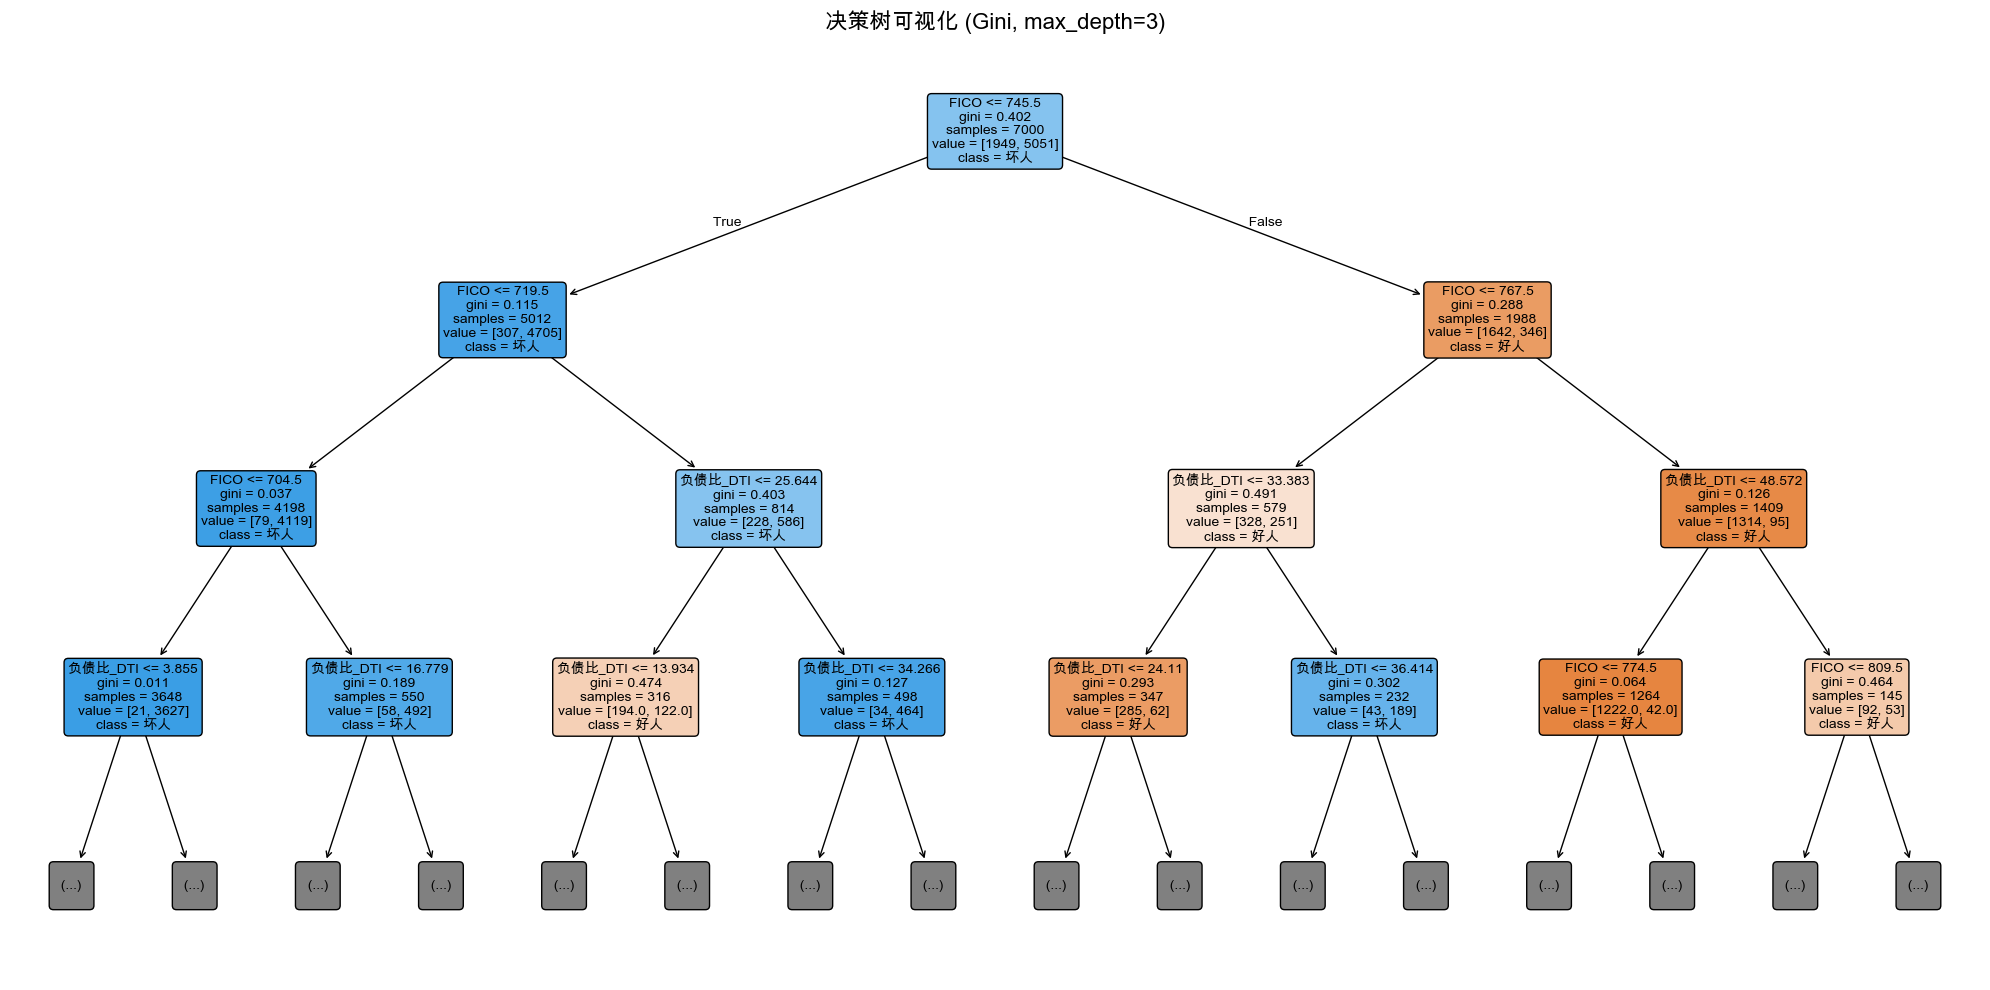

In [27]:
# ============ 可视化决策树 ============
plt.figure(figsize=(20, 10))
plot_tree(
    tree_gini,
    feature_names=X.columns,
    class_names=['好人', '坏人'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3  # 只显示前3层，不然太密
)
plt.title('决策树可视化 (Gini, max_depth=3)', fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
# ============ Gini Importance（内置） ============
gini_imp = pd.DataFrame({
    '特征': X.columns,
    'Gini重要性': tree_gini.feature_importances_
}).sort_values('Gini重要性', ascending=False)

print("=" * 60)
print("⚠️ 决策树内置的 Gini Importance")
print("=" * 60)
print(gini_imp.to_string(index=False))

# 注意观察："虚假ID_高基数" 是否排进了前几名？
# 虽然它和违约毫无逻辑关系，但因为取值多，树会偏爱它！

⚠️ 决策树内置的 Gini Importance
      特征  Gini重要性
    FICO 0.850646
 负债比_DTI 0.149354
      收入 0.000000
    工作年限 0.000000
  信用卡使用率 0.000000
虚假ID_高基数 0.000000


In [21]:
# ============ 手动实现 Permutation Importance（万能兼容版） ============
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold

print("\n⏳ 正在手动计算 Permutation Importance...")

n_repeats = 10
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

all_importances = {col: [] for col in X_test.columns}

for fold_idx, (val_idx, _) in enumerate(skf.split(X_test, y_test)):
    X_val = X_test.iloc[val_idx]
    y_val = y_test.iloc[val_idx]
    baseline_auc = roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])
    
    for col in X_test.columns:
        fold_importances = []
        for _ in range(n_repeats):
            X_val_permuted = X_val.copy()
            X_val_permuted[col] = np.random.permutation(X_val[col].values)
            permuted_auc = roc_auc_score(y_val, rf.predict_proba(X_val_permuted)[:, 1])
            fold_importances.append(baseline_auc - permuted_auc)
        all_importances[col].extend(fold_importances)

perm_imp = pd.DataFrame({
    '特征': X_test.columns,
    '重要性均值': [np.mean(all_importances[col]) for col in X_test.columns],
    '重要性标准差': [np.std(all_importances[col]) for col in X_test.columns]
}).sort_values('重要性均值', ascending=False)

perm_imp['显著有用'] = (perm_imp['重要性均值'] - 2 * perm_imp['重要性标准差']) > 0

print("\n✅ Permutation Importance（手动实现）")
print(perm_imp.to_string(index=False))


⏳ 正在手动计算 Permutation Importance...

✅ Permutation Importance（手动实现）
      特征    重要性均值   重要性标准差  显著有用
    FICO 0.449796 0.014551  True
 负债比_DTI 0.048215 0.003449  True
  信用卡使用率 0.000976 0.000455  True
      收入 0.000510 0.000509 False
    工作年限 0.000417 0.000350 False
虚假ID_高基数 0.000097 0.000489 False


In [22]:
# ============ 合并对比 ============
# 提取随机森林的 Gini importance
rf_gini = pd.DataFrame({
    '特征': X.columns,
    'RF_Gini重要性': rf.feature_importances_
})

compare_df = gini_imp.merge(rf_gini, on='特征').merge(perm_imp, on='特征')
compare_df = compare_df[['特征', 'Gini重要性', 'RF_Gini重要性', '重要性均值', '重要性标准差', '显著有用']]

print("=" * 60)
print("📊 三种重要性指标对比")
print("=" * 60)
print(compare_df.to_string(index=False))

print("\n" + "=" * 60)
print("💡 结论：")
print("=" * 60)
print("1. '虚假ID_高基数' 在 Gini Importance 中虚高（因为取值多）")
print("2. 在 Permutation Importance 中，它接近 0 且统计不显著")
print("3. 说明这个变量对预测坏账毫无帮助，应该剔除！")

📊 三种重要性指标对比
      特征  Gini重要性  RF_Gini重要性    重要性均值   重要性标准差  显著有用
    FICO 0.850646    0.738687 0.449796 0.014551  True
 负债比_DTI 0.149354    0.117339 0.048215 0.003449  True
      收入 0.000000    0.038512 0.000510 0.000509 False
    工作年限 0.000000    0.025672 0.000417 0.000350 False
  信用卡使用率 0.000000    0.040750 0.000976 0.000455  True
虚假ID_高基数 0.000000    0.039041 0.000097 0.000489 False

💡 结论：
1. '虚假ID_高基数' 在 Gini Importance 中虚高（因为取值多）
2. 在 Permutation Importance 中，它接近 0 且统计不显著
3. 说明这个变量对预测坏账毫无帮助，应该剔除！


In [23]:
# ============ 合并对比 ============
# 提取随机森林的 Gini importance
rf_gini = pd.DataFrame({
    '特征': X.columns,
    'RF_Gini重要性': rf.feature_importances_
})

compare_df = gini_imp.merge(rf_gini, on='特征').merge(perm_imp, on='特征')
compare_df = compare_df[['特征', 'Gini重要性', 'RF_Gini重要性', '重要性均值', '重要性标准差', '显著有用']]

print("=" * 60)
print("📊 三种重要性指标对比")
print("=" * 60)
print(compare_df.to_string(index=False))

print("\n" + "=" * 60)
print("💡 结论：")
print("=" * 60)
print("1. '虚假ID_高基数' 在 Gini Importance 中虚高（因为取值多）")
print("2. 在 Permutation Importance 中，它接近 0 且统计不显著")
print("3. 说明这个变量对预测坏账毫无帮助，应该剔除！")

📊 三种重要性指标对比
      特征  Gini重要性  RF_Gini重要性    重要性均值   重要性标准差  显著有用
    FICO 0.850646    0.738687 0.449796 0.014551  True
 负债比_DTI 0.149354    0.117339 0.048215 0.003449  True
      收入 0.000000    0.038512 0.000510 0.000509 False
    工作年限 0.000000    0.025672 0.000417 0.000350 False
  信用卡使用率 0.000000    0.040750 0.000976 0.000455  True
虚假ID_高基数 0.000000    0.039041 0.000097 0.000489 False

💡 结论：
1. '虚假ID_高基数' 在 Gini Importance 中虚高（因为取值多）
2. 在 Permutation Importance 中，它接近 0 且统计不显著
3. 说明这个变量对预测坏账毫无帮助，应该剔除！


In [24]:
# ============ RFECV 自动特征筛选 ============
print("\n⏳ 正在运行 RFECV（自动筛选最优特征）...")

rfecv = RFECV(
    estimator=RandomForestClassifier(n_estimators=50, random_state=42),
    step=1,
    cv=5,
    scoring='roc_auc',
    min_features_to_select=2,
    n_jobs=-1
)
rfecv.fit(X_train, y_train)

# 筛选结果
selected = X.columns[rfecv.support_].tolist()
rejected = X.columns[~rfecv.support_].tolist()

print("\n" + "=" * 60)
print("🎯 RFECV 自动筛选结果")
print("=" * 60)
print(f"✅ 选中的特征 ({len(selected)} 个): {selected}")
print(f"❌ 剔除的特征 ({len(rejected)} 个): {rejected}")
print(f"最优特征数量: {rfecv.n_features_}")

# 对比筛选前后的 AUC
rf_full = RandomForestClassifier(n_estimators=50, random_state=42)
rf_full.fit(X_train, y_train)
auc_full = roc_auc_score(y_test, rf_full.predict_proba(X_test)[:, 1])

X_train_selected = X_train[selected]
X_test_selected = X_test[selected]
rf_selected = RandomForestClassifier(n_estimators=50, random_state=42)
rf_selected.fit(X_train_selected, y_train)
auc_selected = roc_auc_score(y_test, rf_selected.predict_proba(X_test_selected)[:, 1])

print(f"\n完整特征 AUC: {auc_full:.4f}")
print(f"筛选后 AUC: {auc_selected:.4f}")
print(f"AUC 变化: {auc_selected - auc_full:.4f} (精简后几乎不降，甚至可能略升)")


⏳ 正在运行 RFECV（自动筛选最优特征）...

🎯 RFECV 自动筛选结果
✅ 选中的特征 (6 个): ['FICO', '收入', '负债比_DTI', '工作年限', '信用卡使用率', '虚假ID_高基数']
❌ 剔除的特征 (0 个): []
最优特征数量: 6

完整特征 AUC: 0.9856
筛选后 AUC: 0.9856
AUC 变化: 0.0000 (精简后几乎不降，甚至可能略升)


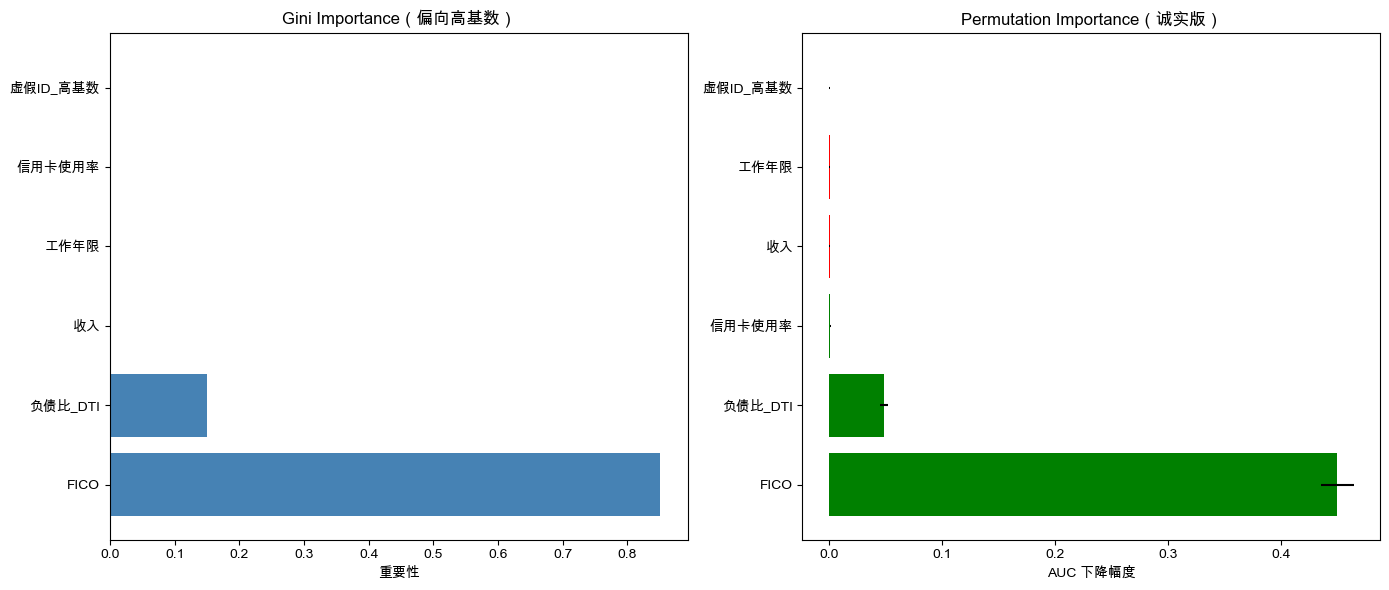


🏁 实验完成！
绿条 = 统计显著有用的特征
红条 = 统计不显著的噪音特征（应该剔除）


In [26]:
# ============ 可视化对比 ============
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左图：Gini Importance（有偏差）
ax1 = axes[0]
gini_sorted = compare_df.sort_values('Gini重要性', ascending=False)
ax1.barh(gini_sorted['特征'], gini_sorted['Gini重要性'], color='steelblue')
ax1.set_title('Gini Importance（偏向高基数）', fontsize=12)
ax1.set_xlabel('重要性')

# 右图：Permutation Importance（诚实）
ax2 = axes[1]
perm_sorted = compare_df.sort_values('重要性均值', ascending=False)
colors = ['green' if x else 'red' for x in perm_sorted['显著有用']]
ax2.barh(perm_sorted['特征'], perm_sorted['重要性均值'], xerr=perm_sorted['重要性标准差'], color=colors)
ax2.set_title('Permutation Importance（诚实版）', fontsize=12)
ax2.set_xlabel('AUC 下降幅度')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("🏁 实验完成！")
print("=" * 60)
print("绿条 = 统计显著有用的特征")
print("红条 = 统计不显著的噪音特征（应该剔除）")